In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import umap

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "report"

# Load precomputed CQTs + metadata (already made in notebook 04)
X_cqt = np.load(PROCESSED_DIR / "windows_cqt.npy")
metadata_df = pd.read_parquet(PROCESSED_DIR / "windows_metadata.parquet")

id_to_name = dict(zip(metadata_df["class_id"], metadata_df["class_name"]))
y_all = metadata_df["class_id"].to_numpy()

print(f"CQT: {X_cqt.shape}")
print(f"Metadata: {metadata_df.shape}")
print(f"Classes: {len(id_to_name)}")

CQT: (19983, 84, 22)
Metadata: (19983, 5)
Classes: 37


In [2]:
def cqt_to_chroma_vector(cqt: np.ndarray) -> np.ndarray:
    """
    Collapse an 84x22 CQT into a 12-dim pitch class vector.
    Sums energy across octaves and time frames.
    Returns L2-normalized 12-dim vector.
    """
    # Convert dB back to linear amplitude for summing
    cqt_linear = 10 ** (cqt / 20.0)
    # Reshape: 84 bins = 7 octaves × 12 pitch classes
    # Bin i corresponds to pitch class (i % 12)
    n_bins, n_frames = cqt.shape
    chroma = np.zeros(12, dtype=np.float32)
    for pc in range(12):
        chroma[pc] = cqt_linear[pc::12, :].sum()
    # L2 normalize so magnitude doesn't dominate
    norm = np.linalg.norm(chroma)
    if norm > 0:
        chroma = chroma / norm
    return chroma


# Compute for all windows
print(f"Computing chroma vectors for {len(X_cqt)} windows...")
X_chroma = np.stack([cqt_to_chroma_vector(X_cqt[i]) for i in tqdm(range(len(X_cqt)))])
print(f"\nX_chroma shape: {X_chroma.shape}")
print(f"Value range: [{X_chroma.min():.3f}, {X_chroma.max():.3f}]")

Computing chroma vectors for 19983 windows...


100%|██████████| 19983/19983 [00:01<00:00, 18600.54it/s]


X_chroma shape: (19983, 12)
Value range: [0.017, 0.805]


PCA explained variance: [0.23602328 0.22133304]
Total variance in 2 components: 0.457


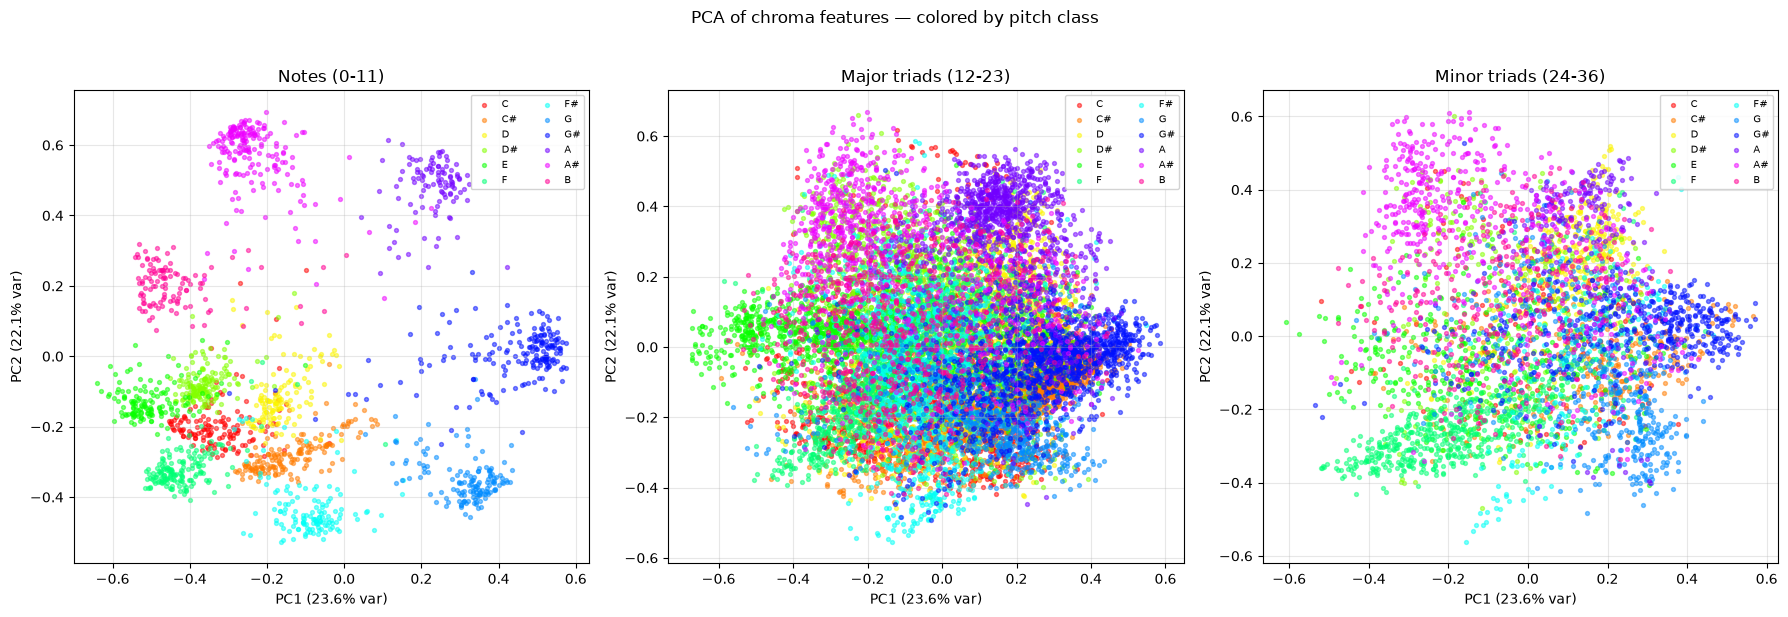


Saved to c:\Users\Constantine\Code\ml-project\report\pca_by_class.png


In [3]:
# Fit PCA on all chroma vectors
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_chroma)

print(f"PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance in 2 components: {pca.explained_variance_ratio_.sum():.3f}")

# Plot — three subplots, one per class type
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Categorical color scheme — one distinct color per pitch class
pitch_colors = plt.cm.hsv(np.linspace(0, 1, 12, endpoint=False))

for ax, (title, class_range) in zip(axes, [
    ("Notes (0-11)", range(0, 12)),
    ("Major triads (12-23)", range(12, 24)),
    ("Minor triads (24-36)", range(24, 36)),
]):
    for cid in class_range:
        mask = y_all == cid
        if mask.sum() == 0:
            continue
        pitch_class = cid % 12
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            s=8, alpha=0.5,
            color=pitch_colors[pitch_class],
            label=id_to_name[cid].split(":")[1],
        )
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=7, ncol=2, framealpha=0.85)

fig.suptitle("PCA of chroma features — colored by pitch class", y=1.02)
plt.tight_layout()
fig.savefig(REPORT_DIR / "pca_by_class.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved to {REPORT_DIR / 'pca_by_class.png'}")

In [5]:
# Flatten CQT to 1D vectors for UMAP
pitch_colors = plt.cm.hsv(np.linspace(0, 1, 12, endpoint=False))
X_cqt_flat = X_cqt.reshape(len(X_cqt), -1).astype(np.float32)
print(f"Flattened CQT shape: {X_cqt_flat.shape}")

# UMAP — n_neighbors controls local vs global structure
# Fewer neighbors = tighter local clusters, larger = smoother global view
print("\nRunning UMAP (this takes 1-3 min)...")
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric="cosine",  # cosine works well for spectrogram-like features
    random_state=42,
)
X_umap = reducer.fit_transform(X_cqt_flat)
print(f"UMAP result shape: {X_umap.shape}")

Flattened CQT shape: (19983, 1848)

Running UMAP (this takes 1-3 min)...


c:\Users\Constantine\Code\ml-project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP result shape: (19983, 2)


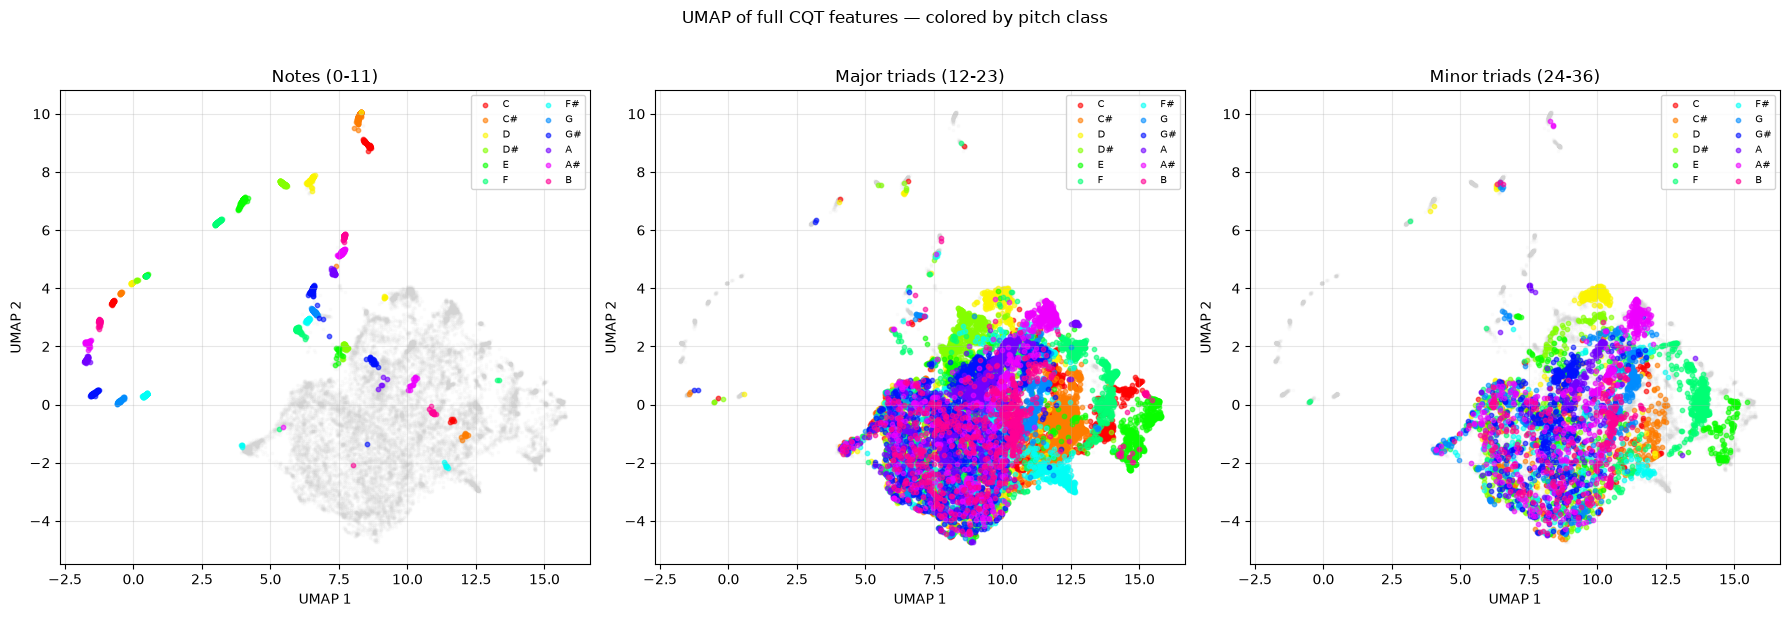


Saved to c:\Users\Constantine\Code\ml-project\report\umap_by_class.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (title, class_range) in zip(axes, [
    ("Notes (0-11)", range(0, 12)),
    ("Major triads (12-23)", range(12, 24)),
    ("Minor triads (24-36)", range(24, 36)),
]):
    # Faint background: all points in gray, so the colored ones stand out
    ax.scatter(X_umap[:, 0], X_umap[:, 1], s=3, alpha=0.05, color="lightgray")

    for cid in class_range:
        mask = y_all == cid
        if mask.sum() == 0:
            continue
        pitch_class = cid % 12
        ax.scatter(
            X_umap[mask, 0], X_umap[mask, 1],
            s=10, alpha=0.6,
            color=pitch_colors[pitch_class],
            label=id_to_name[cid].split(":")[1],
        )
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=7, ncol=2, framealpha=0.85)

fig.suptitle("UMAP of full CQT features — colored by pitch class", y=1.02)
plt.tight_layout()
fig.savefig(REPORT_DIR / "umap_by_class.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved to {REPORT_DIR / 'umap_by_class.png'}")

Note examples: 1751

Unsupervised clustering vs true pitch class labels:
  Adjusted Rand Index (ARI): 0.414    (1.0 = perfect, 0 = random)
  Normalized Mutual Info:    0.637    (1.0 = perfect, 0 = independent)


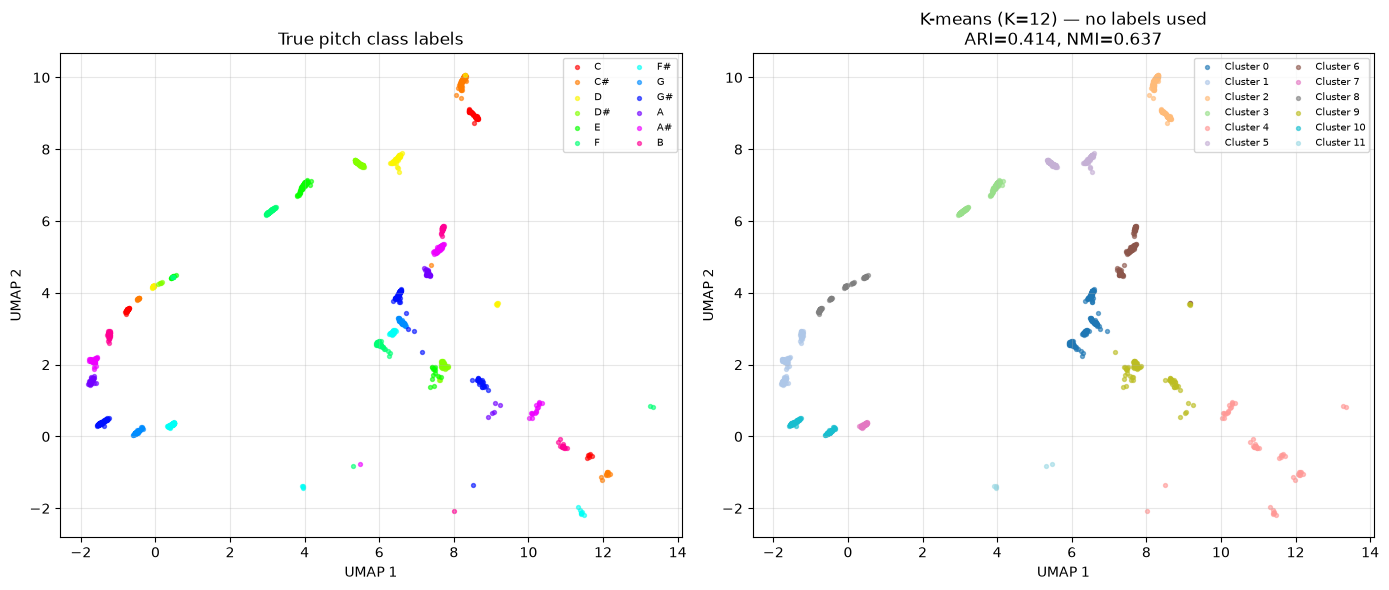


Saved to c:\Users\Constantine\Code\ml-project\report\kmeans_notes_vs_labels.png


In [7]:
# Restrict to note examples (classes 0-11) — where clusters were visible
note_mask = (y_all >= 0) & (y_all < 12)
X_umap_notes = X_umap[note_mask]
y_notes = y_all[note_mask]

print(f"Note examples: {len(X_umap_notes)}")

# K-means with 12 clusters on the UMAP coords of note examples
kmeans = KMeans(n_clusters=12, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(X_umap_notes)

# Score: do the discovered clusters align with true pitch classes?
ari = adjusted_rand_score(y_notes, cluster_ids)
nmi = normalized_mutual_info_score(y_notes, cluster_ids)

print(f"\nUnsupervised clustering vs true pitch class labels:")
print(f"  Adjusted Rand Index (ARI): {ari:.3f}    (1.0 = perfect, 0 = random)")
print(f"  Normalized Mutual Info:    {nmi:.3f}    (1.0 = perfect, 0 = independent)")

# Plot the K-means clusters next to the true labels
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# True pitch class colors
for cid in range(12):
    mask = y_notes == cid
    axes[0].scatter(
        X_umap_notes[mask, 0], X_umap_notes[mask, 1],
        s=8, alpha=0.6, color=pitch_colors[cid],
        label=id_to_name[cid].split(":")[1],
    )
axes[0].set_title("True pitch class labels")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="best", fontsize=7, ncol=2)

# K-means discovered clusters
cluster_colors = plt.cm.tab20(np.linspace(0, 1, 12))
for k in range(12):
    mask = cluster_ids == k
    axes[1].scatter(
        X_umap_notes[mask, 0], X_umap_notes[mask, 1],
        s=8, alpha=0.6, color=cluster_colors[k],
        label=f"Cluster {k}",
    )
axes[1].set_title(f"K-means (K=12) — no labels used\nARI={ari:.3f}, NMI={nmi:.3f}")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="best", fontsize=7, ncol=2)

plt.tight_layout()
fig.savefig(REPORT_DIR / "kmeans_notes_vs_labels.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved to {REPORT_DIR / 'kmeans_notes_vs_labels.png'}")

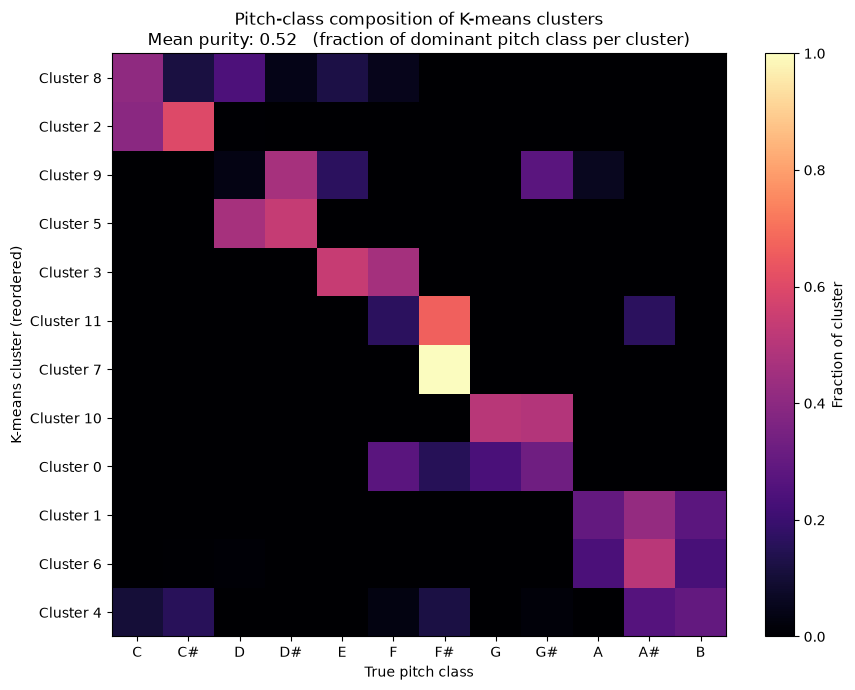


Saved to c:\Users\Constantine\Code\ml-project\report\kmeans_cluster_purity.png
Mean cluster purity: 0.524


In [8]:
# For each K-means cluster, count how many of each true pitch class it contains
cluster_composition = np.zeros((12, 12), dtype=np.int32)
for k in range(12):
    in_cluster = cluster_ids == k
    for p in range(12):
        cluster_composition[k, p] = int(((y_notes == p) & in_cluster).sum())

# Normalize rows so each cluster sums to 1 (what fraction of the cluster is each pitch class)
row_sums = cluster_composition.sum(axis=1, keepdims=True)
cluster_purity = cluster_composition / np.maximum(row_sums, 1)

# What is the dominant pitch class of each cluster?
dominant_pitch = cluster_purity.argmax(axis=1)
purity_score = cluster_purity.max(axis=1)

# Reorder rows by dominant pitch class for a diagonal-friendly heatmap
order = np.argsort(dominant_pitch)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cluster_purity[order], cmap="magma", vmin=0, vmax=1, aspect="auto")

pitch_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
ax.set_xticks(range(12))
ax.set_xticklabels(pitch_names)
ax.set_yticks(range(12))
ax.set_yticklabels([f"Cluster {k}" for k in order])
ax.set_xlabel("True pitch class")
ax.set_ylabel("K-means cluster (reordered)")
ax.set_title(
    "Pitch-class composition of K-means clusters\n"
    f"Mean purity: {purity_score.mean():.2f}   (fraction of dominant pitch class per cluster)"
)
fig.colorbar(im, ax=ax, label="Fraction of cluster")

plt.tight_layout()
fig.savefig(REPORT_DIR / "kmeans_cluster_purity.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved to {REPORT_DIR / 'kmeans_cluster_purity.png'}")
print(f"Mean cluster purity: {purity_score.mean():.3f}")